# 07 · Transformer tabular: atenção entre as variáveis do paciente

O Transformer é a arquitetura por trás do BERT, do GPT e dos modelos da Hugging Face. Seu
ingrediente central é a **atenção**: ao processar um elemento, a rede decide quanto
"olhar" para cada um dos outros. Em texto, os elementos são palavras; aqui, são as
**variáveis do paciente**.

| Conceito dos slides | Em texto | Neste notebook |
|:--|:--|:--|
| Token | uma palavra | uma variável (idade, pressão, colesterol…) |
| Embedding | vetor aprendido para cada palavra | vetor aprendido para cada variável e cada valor |
| Query, Key, Value | projeções de cada palavra | projeções de cada variável |
| Atenção múltipla | várias "cabeças" olhando relações diferentes | 4 cabeças |
| Token `[CLS]` | resume a frase para classificação (BERT) | resume o paciente para prever `cardio` |
| Codificação posicional | a ordem das palavras importa | **não usada**: a ordem das colunas não significa nada |

Três perguntas: (1) o Transformer supera o MLP? (2) para quais variáveis o token `[CLS]`
olha ao decidir? (3) isso bate com a explicabilidade do notebook 06?

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.dados import preparar
from src.model import avaliacao, mlp_keras, treino
from src.model import transformer_tabular as tt
from src.utils import graficos
from src.utils.io import configurar_estilo, ler_tabela, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "07-transformer-tabular"
particao = P = preparar()
ROTULO_TOKEN = {"[CLS]": "[CLS]", **config.ROTULOS}

## 1. Da variável ao token

Cada variável ganha sua própria camada de embedding. Uma variável contínua (já
padronizada) vira `valor × w + b`, ou seja, um vetor próprio de 32 dimensões esticado pelo valor.
Uma categórica em one-hot vira o vetor do seu nível, como uma tabela de embeddings de
palavras. São 12 tokens de variáveis + 1 token `[CLS]`.

In [2]:
tokens = pd.DataFrame(
    [{"token": config.ROTULOS[nome], "colunas_de_entrada": ", ".join(P.nomes[i:f]), "n_colunas": f - i}
     for nome, i, f in tt.GRUPOS]
).set_index("token")
salvar_tabela(tokens, SECAO, "tokens")
tokens

,colunas_de_entrada,n_colunas
token,,
Idade (anos),idade_anos,1
Altura (cm),height,1
Peso (kg),weight,1
IMC,imc,1
Pressão sistólica,ap_hi,1
Pressão diastólica,ap_lo,1
Colesterol,"cholesterol_1, cholesterol_2, cholesterol_3",3
Glicose,"gluc_1, gluc_2, gluc_3",3
Sexo masculino,sexo_masculino,1


## 2. Treino

Dimensão dos tokens 32, 4 cabeças de atenção, 2 blocos de codificador, AdamW e a mesma parada
antecipada pela AUC de validação usada nas outras redes.

Parâmetros: 18.113


Épocas: 22


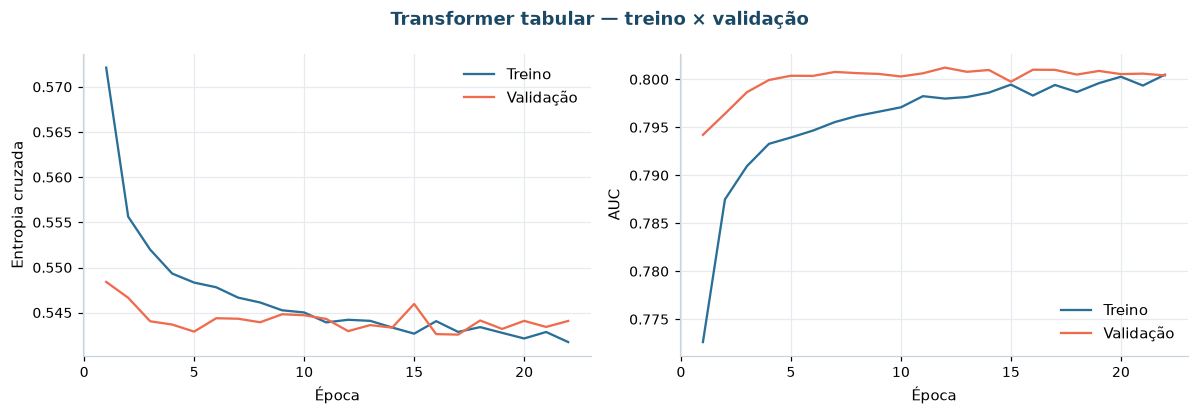

In [3]:
transformer, modelo_atencao = tt.construir_transformer(P.n_entradas, dim=32, cabecas=4, blocos=2)
print(f"Parâmetros: {transformer.count_params():,}".replace(",", "."))
hist = mlp_keras.treinar(transformer, P.X_treino, P.y_treino, P.X_val, P.y_val, paciencia=10)
print(f"Épocas: {len(hist.history['loss'])}")
fig, dados = graficos.curvas_de_treino(hist.history, "Transformer tabular — treino × validação")
salvar_figura(fig, SECAO, "curvas-treino", dados)
plt.show()

## 3. Transformer × MLP no teste

Mesmo critério de sempre: limiar escolhido na validação para sensibilidade ≥ 80 %,
avaliação uma única vez no teste e diferença de AUC por bootstrap pareado contra o MLP
final (o mesmo modelo da aplicação).

In [4]:
mlp, _, _ = treino.carregar_modelo_final()
modelos = {"Transformer tabular": transformer, "MLP Keras (modelo final)": mlp}
resultados, prob_teste = {}, {}
for nome, modelo in modelos.items():
    p_val = mlp_keras.prever(modelo, P.X_val)
    prob_teste[nome] = mlp_keras.prever(modelo, P.X_teste)
    resultados[nome] = avaliacao.metricas(P.y_teste, prob_teste[nome], avaliacao.escolher_limiar(P.y_val, p_val))
comparacao = avaliacao.tabela_comparativa(resultados)
comparacao["parametros"] = [modelos[m].count_params() for m in comparacao.index]
salvar_tabela(comparacao, SECAO, "comparacao-teste")

diferenca = avaliacao.bootstrap_diferenca_auc(P.y_teste, prob_teste["Transformer tabular"], prob_teste["MLP Keras (modelo final)"])
print(f"AUC Transformer − MLP: {diferenca['diferenca']:+.4f}  IC 95% [{diferenca['ic95_inf']:+.4f}, {diferenca['ic95_sup']:+.4f}]")
salvar_tabela(pd.DataFrame([diferenca], index=["Transformer − MLP"]), SECAO, "diferenca-pareada")
comparacao

AUC Transformer − MLP: -0.0004  IC 95% [-0.0017, +0.0008]


,auc_roc,auc_pr,acuracia,sensibilidade,especificidade,precisao,f1,brier,limiar,parametros
MLP Keras (modelo final),0.8014,0.7860,0.7176,0.8078,0.6293,0.6809,0.7389,0.1803,0.3820,3713
Transformer tabular,0.8010,0.7848,0.7155,0.8113,0.6216,0.6774,0.7383,0.1810,0.3375,18113


## 4. Para onde a rede olha: mapas de atenção

Cada linha do mapa é um token fazendo uma **pergunta** (query) e cada coluna, um token
consultado (key); o valor é o peso da atenção, e cada linha soma 1. A linha mais
interessante é a do `[CLS]`, porque é dela que sai a previsão: ela mostra quais
variáveis a rede consulta para decidir.

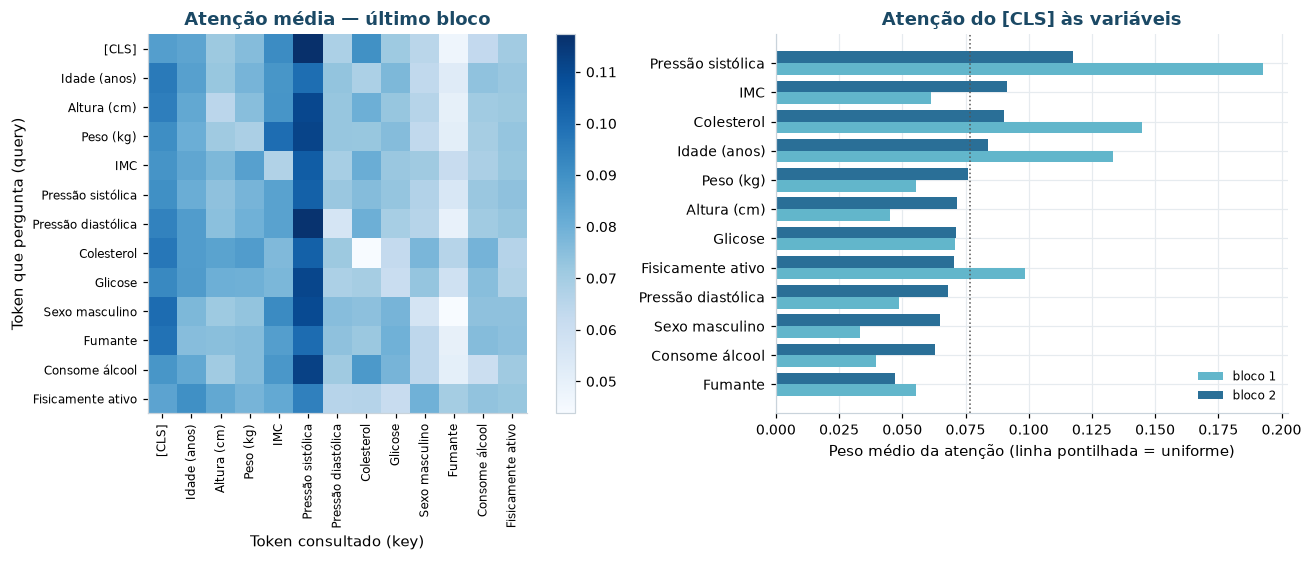

In [5]:
amostra = P.X_teste[:3000]
fig, eixos = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})
mapa = tt.atencao_media(modelo_atencao, amostra, bloco=-1)
rotulos = [ROTULO_TOKEN[t] for t in tt.TOKENS]
im = eixos[0].imshow(mapa, cmap="Blues")
eixos[0].grid(False)
eixos[0].set_xticks(range(len(rotulos)), rotulos, rotation=90, fontsize=8)
eixos[0].set_yticks(range(len(rotulos)), rotulos, fontsize=8)
eixos[0].set(title="Atenção média — último bloco", xlabel="Token consultado (key)", ylabel="Token que pergunta (query)")
fig.colorbar(im, ax=eixos[0], fraction=0.046)

linhas_cls = {f"bloco {b + 1}": tt.atencao_media(modelo_atencao, amostra, bloco=b)[0, 1:] for b in range(2)}
atencao_cls = pd.DataFrame(linhas_cls, index=[config.ROTULOS[t] for t in tt.TOKENS[1:]])
ordem = atencao_cls.sort_values("bloco 2")
altura = np.arange(len(ordem))
eixos[1].barh(altura - 0.2, ordem["bloco 1"], height=0.4, color=config.AZUL_CLARO, label="bloco 1")
eixos[1].barh(altura + 0.2, ordem["bloco 2"], height=0.4, color=config.AZUL_COBALTO, label="bloco 2")
eixos[1].set_yticks(altura, ordem.index)
eixos[1].axvline(1 / 13, color="#555", linestyle=":", linewidth=1)
eixos[1].set(title="Atenção do [CLS] às variáveis", xlabel="Peso médio da atenção (linha pontilhada = uniforme)")
eixos[1].legend(fontsize=8)
fig.tight_layout()
salvar_figura(fig, SECAO, "mapas-atencao", pd.DataFrame(mapa, index=rotulos, columns=rotulos))
salvar_tabela(atencao_cls, SECAO, "atencao-cls")
plt.show()

### Atenção × importância por permutação

A atenção diz **para onde a rede olha**, não necessariamente **o que muda a decisão**, e a
literatura alerta que atenção não é explicação por si só (Jain & Wallace, 2019). Por
isso vale comparar com a importância por permutação do notebook 06, que mede o efeito real
de cada variável na AUC.

In [6]:
from scipy.stats import spearmanr

permutacao = ler_tabela("06-explicabilidade", "importancia-permutacao")["queda_auc"]
confronto = atencao_cls.join(permutacao.rename("queda_auc_permutacao"))
confronto["posicao_permutacao"] = confronto["queda_auc_permutacao"].rank(ascending=False).astype(int)
resumo = []
for bloco in ["bloco 1", "bloco 2"]:
    confronto[f"posicao_{bloco}"] = confronto[bloco].rank(ascending=False).astype(int)
    rho, p_valor = spearmanr(confronto[bloco], confronto["queda_auc_permutacao"])
    resumo.append({
        "bloco": bloco,
        "concentracao": confronto[bloco].max() * len(confronto),  # 1 = atenção uniforme
        "variavel_mais_atendida": confronto[bloco].idxmax(),
        "spearman_com_permutacao": rho,
        "p_valor": p_valor,
    })
resumo = pd.DataFrame(resumo).set_index("bloco").round(3)
salvar_tabela(confronto.sort_values("posicao_permutacao"), SECAO, "atencao-vs-permutacao")
salvar_tabela(resumo, SECAO, "atencao-resumo-blocos")
display(resumo)
confronto.sort_values("posicao_permutacao")

,concentracao,variavel_mais_atendida,spearman_com_permutacao,p_valor
bloco,,,,
bloco 1,2.313,Pressão sistólica,0.867,0.000
bloco 2,1.408,Pressão sistólica,0.720,0.008


,bloco 1,bloco 2,queda_auc_permutacao,posicao_permutacao,posicao_bloco 1,posicao_bloco 2
Pressão sistólica,0.192757,0.117331,0.183381,1,1,1
Idade (anos),0.133296,0.083726,0.031808,2,3,4
Colesterol,0.144859,0.090044,0.029185,3,2,3
Pressão diastólica,0.048598,0.067993,0.003224,4,9,9
IMC,0.061487,0.091438,0.002831,5,6,2
Fisicamente ativo,0.098497,0.070348,0.002464,6,4,8
Glicose,0.070809,0.071265,0.002128,7,5,7
Peso (kg),0.055468,0.075813,0.001107,8,7,5
Fumante,0.055383,0.047073,0.000973,9,8,12
Altura (cm),0.044995,0.071638,0.000708,10,10,6


## Conclusões

* **Desempenho:** o Transformer, com ~18 mil parâmetros, empata com o MLP de ~3,7 mil
  (IC pareado da diferença contém zero). É o mesmo teto de ~0,80 de todos os outros
  modelos: a atenção não cria informação que as 16 variáveis não têm. Na literatura, o
  FT-Transformer só costuma se destacar em bases tabulares maiores e com mais variáveis.
* **Para onde a rede olha:** o token `[CLS]` concentra a atenção na **pressão sistólica**,
  com peso bem acima do uniforme, seguida (conforme o bloco e a execução) de idade,
  colesterol ou IMC. A ordem da atenção se correlaciona com a importância por permutação. A rede
  chegou sozinha à mesma hierarquia do notebook 06.
* **Cuidado ao ler a atenção:** o padrão exato **muda entre execuções**. Em todas as que
  fizemos, pelo menos um bloco pôs a pressão sistólica em primeiro lugar. Mas numa delas
  o segundo bloco ficou quase uniforme, sem correlação com a permutação. Depois do primeiro
  bloco, cada token já misturou informação dos outros, e o "token da idade" deixa de ser só
  a idade. Por isso a atenção é uma **pista** sobre o funcionamento da rede, não uma
  explicação. SHAP e permutação (notebook 06) continuam sendo as ferramentas certas para
  explicar decisões.
* **Por que fazer, então?** Para ver na prática as peças do Transformer dos slides
  (embeddings, Query/Key/Value, atenção múltipla, `[CLS]`, blocos com normalização e
  conexões residuais) num problema real. A mesma arquitetura, com tokens de palavras em
  vez de variáveis, é a base dos modelos de linguagem que o agente do notebook 09 usa.